<a href="https://colab.research.google.com/github/RaziehSh1987/Python_Data-Analysis/blob/main/Python(Data_analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Read from files

In [ ]:
import numpy as np
import pandas as pd

df=pd.read_csv("/content/data.csv", encoding='cp1252')

#Read from Excel
# pd.read_excel("/content/sample_data/data.xlsx",sheet_name="Sheet_name")

#Read and write from json
# import json
# with open("file.json", 'r',encoding='utf-8') as f:
#   cfg=json.load(f)
# cfg["threshold_mm"]=2.0

# with open("file.json", 'w',encoding='utf-8') as f:
#   json.dump(cfg,f,indent=2)


/tmp/ipykernel_539/3738351033.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/data.csv", encoding='cp1252')


In [ ]:
df.info() # show dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

In [ ]:
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


#replace Non value (missing value) with 0

In [ ]:
df=df.fillna(0)


#Detect missing columns

In [ ]:

require_col={'stn_code','location','type','so2','no2'}
missing=require_col- set(df.columns)
if missing:
  raise ValueError(f'Missing columns: {missing}')
print(df.dtypes)

stn_code                        object
sampling_date                   object
state                           object
location                        object
agency                          object
type                            object
so2                            float64
no2                            float64
rspm                           float64
spm                            float64
location_monitoring_station     object
pm2_5                          float64
date                            object
dtype: object


#Example: must be non-negative

In [ ]:
neg_so2=df['so2']<0
if neg_so2.any():
  bad_rows=df.loc[neg_so2,['stn_code','location','type','so2','no2']]
  raise ValueError(f'negative value found in :\n {bad_rows}')


#Missing value check

In [ ]:
if df['stn_code'].isna().any():
  n=df['stn_code'].isna().sum()
  raise ValueError(f'stn_code has {n} missing values')


#Standardize
- Case 1 — regex=False (literal text)
df["sampling_date"].str.replace(" - M", " ", regex=False)
  - Meaning:  Replace the exact text " - M" with " ".
  - Example:  "February - M021990" => "February 021990"
- Case 2 — regex=True (pattern matching)

  - Example: df["sampling_date"].str.replace(r"M\d+", "", regex=True)

  - Pattern: M\d+  means => letter M followed by digits

  - Example transformation: February - M021990 becomes => February -

- Meaning of errors='coerce' It means:  If a value cannot be converted, replace it with NaN (or NaT for datetime) instead of raising an error.


In [ ]:
df['sampling_date']=df['sampling_date'].astype(str) # cast to string
df['sampling_date']=(df['sampling_date'].str.replace(' - M'," ",regex=False)) # remove unclear data like - M
print(df['sampling_date'])

0         February 021990
1         February 021990
2         February 021990
3            March 031990
4            March 031990
               ...       
435737           24-12-15
435738           29-12-15
435739                nan
435740                nan
435741                nan
Name: sampling_date, Length: 435742, dtype: object


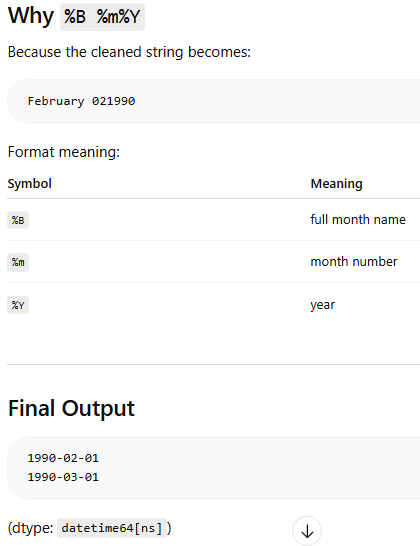

In [ ]:
df['sampling_date_1']=pd.to_datetime(df['sampling_date'],format='%B %m%Y',errors='coerce') #%B= full month name February() %y=year
print(df['sampling_date_1'])

0        1990-02-01
1        1990-02-01
2        1990-02-01
3        1990-03-01
4        1990-03-01
            ...    
435737          NaT
435738          NaT
435739          NaT
435740          NaT
435741          NaT
Name: sampling_date_1, Length: 435742, dtype: datetime64[ns]


In [ ]:
print(np.count_nonzero(df)) #befor removing duplicate

dup=df.duplicated(set(df.columns),keep=False)
print(dup.sum()) # number of duplicate data

dup_df=df.drop_duplicates(set(df.columns),keep="last")
print(np.count_nonzero(dup_df))# after removing doplicate data


6096749
1348
6087324


   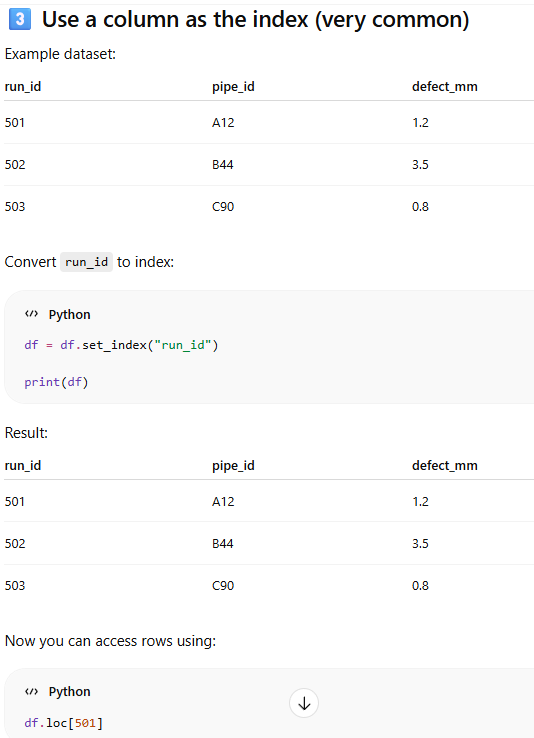

- indexing and sorting:
df.set_index(["run_id","pipe_id"]).sort_index()

In [ ]:
# df = df.set_index("run_id") # set a unique column as a index column
print(df[df['so2']>3.5].head(4))
print(df.loc[2,["stn_code","state"]])
# print(df)

  stn_code    sampling_date           state   location agency  \
0    150.0  February 021990  Andhra Pradesh  Hyderabad    NaN   
2    152.0  February 021990  Andhra Pradesh  Hyderabad    NaN   
3    150.0     March 031990  Andhra Pradesh  Hyderabad    NaN   
4    151.0     March 031990  Andhra Pradesh  Hyderabad    NaN   

                                 type  so2   no2  rspm  spm  \
0  Residential, Rural and other Areas  4.8  17.4   NaN  NaN   
2  Residential, Rural and other Areas  6.2  28.5   NaN  NaN   
3  Residential, Rural and other Areas  6.3  14.7   NaN  NaN   
4                     Industrial Area  4.7   7.5   NaN  NaN   

  location_monitoring_station  pm2_5        date sampling_date_1  
0                         NaN    NaN  1990-02-01      1990-02-01  
2                         NaN    NaN  1990-02-01      1990-02-01  
3                         NaN    NaN  1990-03-01      1990-03-01  
4                         NaN    NaN  1990-03-01      1990-03-01  
stn_code             15

In [ ]:
dff = pd.DataFrame({"a":[10,20,30], "b":[1,2,3]}, index=[100,101,102])
print(dff)

      a  b
100  10  1
101  20  2
102  30  3


In [ ]:
print(dff.loc[102])
print(dff.iloc[1])

a    30
b     3
Name: 102, dtype: int64
a    20
b     2
Name: 101, dtype: int64


In [ ]:
print(dff[dff['b']>2])

      a  b
102  30  3


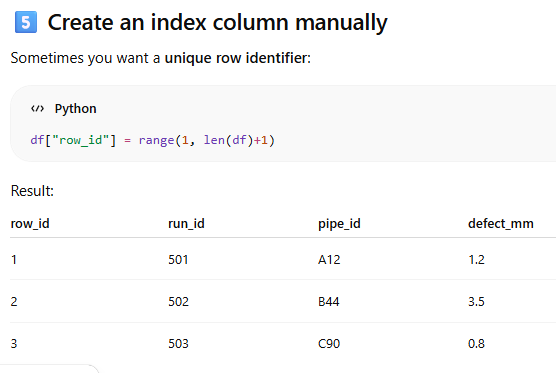

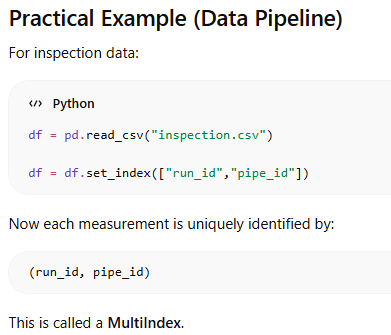

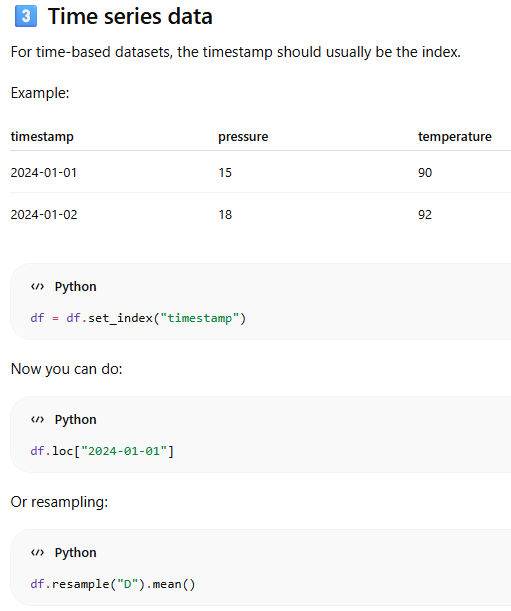

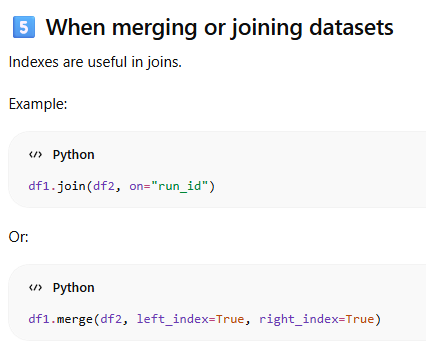

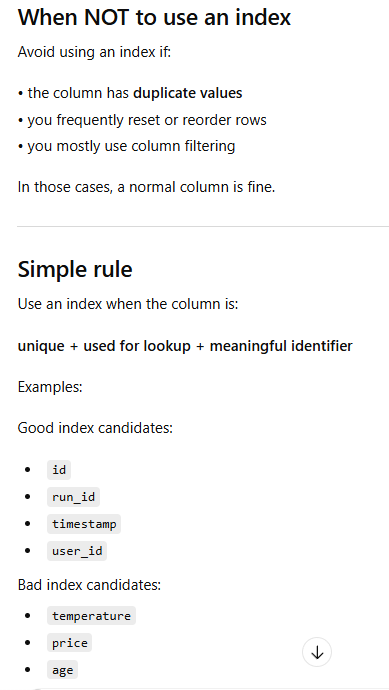

In [ ]:
print(len(dff))
dff["row_index"]=range(1,len(dff)+1)
print(dff)

3
      a  b  row_index
100  10  1          1
101  20  2          2
102  30  3          3


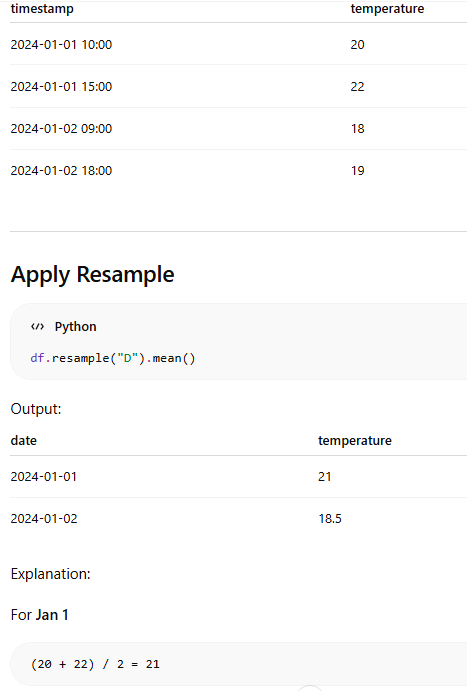

# resample("D") means:

Group the data by Day  Then .mean() means:

Compute the average value for each day

In [ ]:
df=df.set_index('sampling_date_1')
df.resample("D").mean()

# groupby("pipe_id")
- df.groupby("pipe_id")
- It groups rows that belong to the same pipe.
    - Group A12
   1.2
   2.0
    - Group B44
   3.5
   2.9
 - .agg() (Aggregation) -> This calculates summary statistics for each group.
 - avg_defect=("defect_mm", "mean") -> Average defect size per pipe
 - max_defect=("defect_mm", "max") -> Maximum defect size in that pipe
 - n=("defect_mm", "size") -> Count how many inspections exist
- .reset_index() -> After groupby, pipe_id becomes the index.  This line converts it back into a normal column.



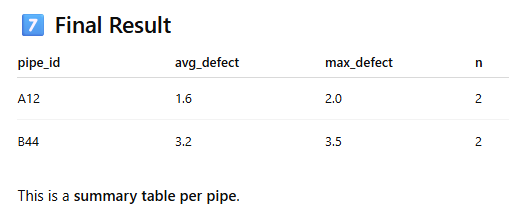

##  Then store as a CSV file:

In [ ]:
kpi=(df.groupby('location').agg(avg=('so2','mean'),
                                max=('so2',"max"),
                                number=('so2','size')).reset_index())
print(kpi)
kpi.to_csv("location.csv", index=False)

           location        avg    max  number
0        ANKLESHWAR  18.940120   26.0     167
1              Agra   6.168916   49.0    7306
2         Ahmedabad  14.184336  166.3    6256
3            Aizawl   2.090873    8.0    3499
4             Akola   7.937023   13.0    1048
..              ...        ...    ...     ...
299        Warangal   5.484000   39.0     630
300         Wayanad   2.006445    5.3     512
301  West Singhbhum  20.947020   40.0     151
302    Yamuna Nagar  20.518885   47.0     329
303     Yamunanagar  14.880303   40.8     220

[304 rows x 4 columns]


## store in a Database:

In [ ]:
import  psycopg2
conn=psycopg2.connect(
    host='localhost',
    database='inspection_db',
    user='user',
    password='password'
)

kpi.to_sql("new_database_name",conn,if_exists='replace')

## Merge it with the original dataset:

In [ ]:
df=df.merge(kpi,on='location',how='left')
print(df)

## Logging

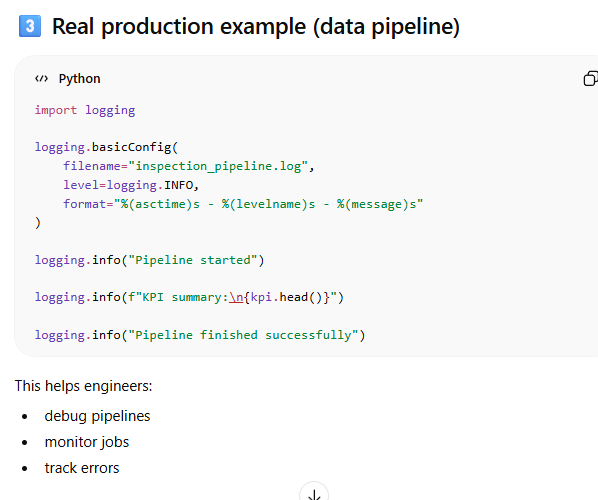

In [ ]:
import logging
logging.basicConfig(filename='appLog.log',level=logging.INFO,format='%(asctime)s:%(levelname)s:%(message)s')
logging.info(f"avg detect per location {kpi.head(5)}")

## Pivot:

In [ ]:
pivot_table=df.pivot(index="column_name" , columns="column_name", values="column_name_numbers")

# Apply:
- .apply() runs a Python function on every row or value.
- .apply() is slow because:

    - It runs pure Python loops

    - Pandas cannot optimize it

    - It does row-by-row processing

    - If you have 1 million rows, .apply() may take seconds.

In [ ]:
def bucket(mm:float) -> str:
  if mm<1:
    return "low"
  elif mm<3:
    return "mid"
  return "high"

df['severity']=df['so2'].apply(bucket)
print(df.head(4)[['severity','so2','location']])

  severity  so2   location
0     high  4.8  Hyderabad
1     high  3.1  Hyderabad
2     high  6.2  Hyderabad
3     high  6.3  Hyderabad


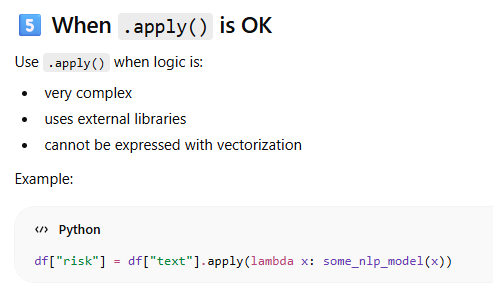

# Vectorized operations (recommended)

- Vectorized operations use NumPy internally, which runs in compiled C code, so it's much faster.


In [ ]:
df['severity_2']=np.select([df['so2']<1 , df['so2']<3],['low','mid'],default='high')
print(df.head(4)[['severity_2','so2','location']])

  severity_2  so2   location
0       high  4.8  Hyderabad
1       high  3.1  Hyderabad
2       high  6.2  Hyderabad
3       high  6.3  Hyderabad


- Another vectorized option (very common)

    - Using np.where():

In [ ]:
df['severity_3']= np.where(df['so2']<1,'low',np.where(df['so2']<3,'mid','high'))
print(df.head(4)[['severity_3','so2','location']])

  severity_3  so2   location
0       high  4.8  Hyderabad
1       high  3.1  Hyderabad
2       high  6.2  Hyderabad
3       high  6.3  Hyderabad


# Logging
- Logging is used to record what your program is doing while it runs, especially in production scripts and data pipelines. Instead of using print(), engineers use the logging module because it is structured, configurable, and can write to files or monitoring systems.

Let’s explain your example step by step.


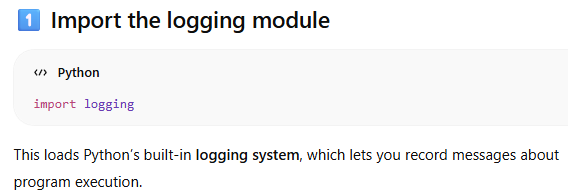

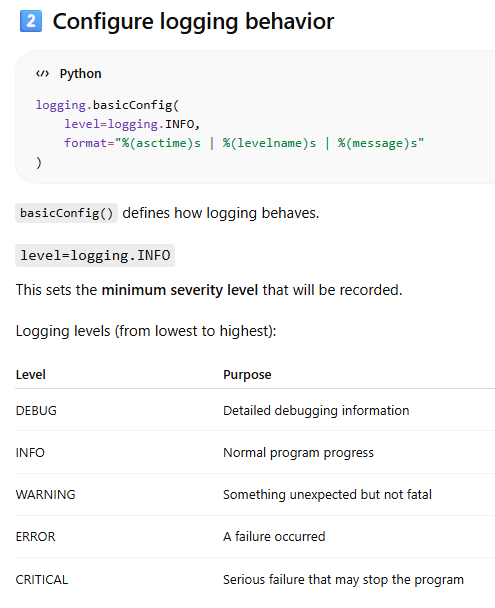

So with INFO, Python will show:

- INFO
- WARNING
- ERROR
- CRITICAL

but not DEBUG.

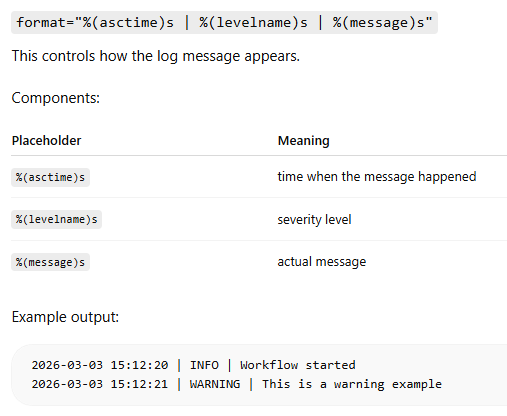

In [ ]:
import logging
logging.basicConfig(
    filename="logs/test.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

## Writing log messages
INFO message

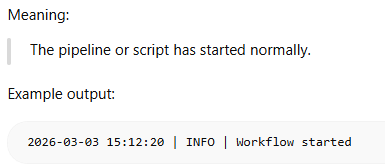

In [ ]:
logging.info("workflow Started")


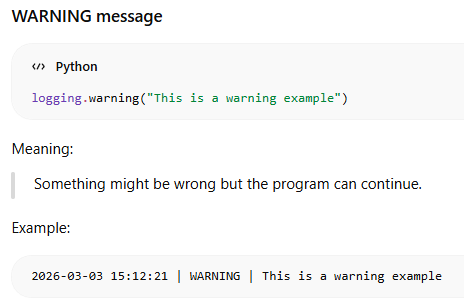

In [ ]:
logging.warning("this is a warning example")

# return Current work Directory

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'location.csv', 'data.csv', 'sample_data']


# ArgParse
- argparse is used to build command-line tools in Python.
Instead of hard-coding values inside the script, you pass parameters when running the script. This is extremely common in automation pipelines, cron jobs, CI pipelines, and data processing workflows.

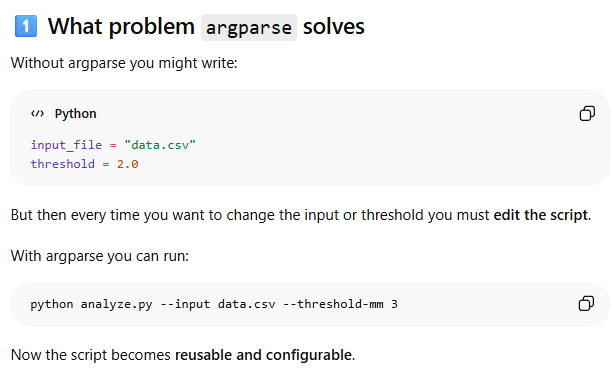

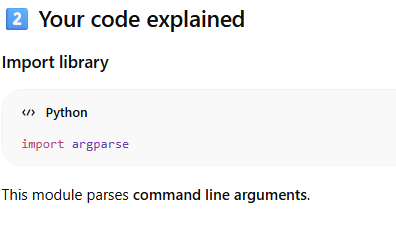

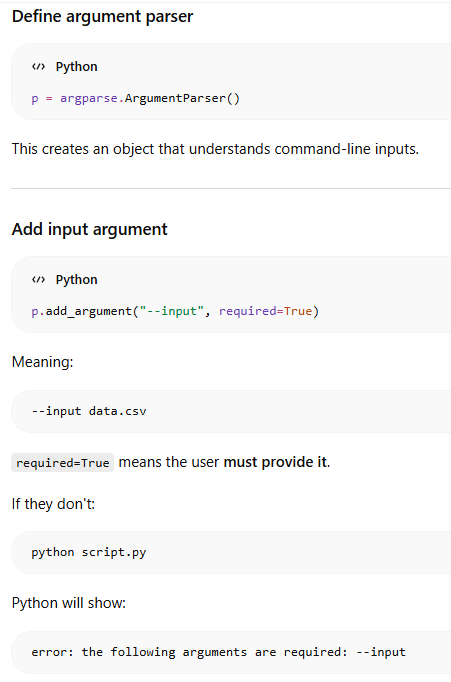

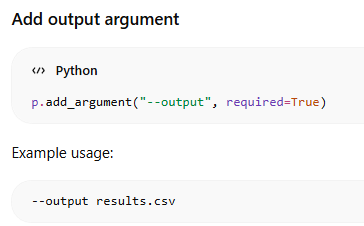

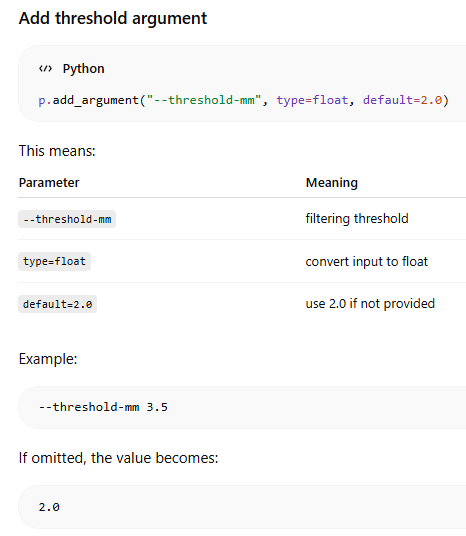

# Real Data Pipeline Example
Imagine a defect filtering pipeline:

In [ ]:
import argparse #This module parses command line arguments.
import pandas as pd

def parse_args():
  p=argparse.ArgumentParser() # creates an object

  p.add_argument("--input", required=True) #Add input argument / required=True means the user must provide it.

  p.add_argument("--output",required=True) # ex: --output results.csv
  p.add_argument("--threshold-mm",type=float,default=2.0) #filtering threshold

  return p.parse_args()  # This reads the command line and returns an object.

def main():
 args=parse_args()
 df=pd.read_csv(args.input)
 df=df[df['defect_mm']>=args.threshold-mm]
 df.to_csv(args.output,index=False)


if __name__=="__main__":   # script runs only when executed directly, Not when imported as a module.
  main()


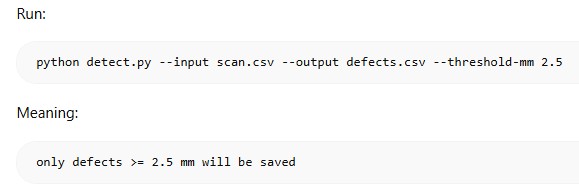

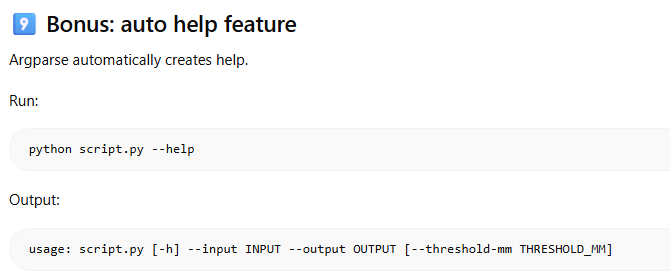

#Analysts might run pipelines like:

python pipeline.py \
   --input ultrasonic_scan.parquet \
   --output defect_report.csv \
   --threshold-mm 2

 - So they don't edit the code, they just pass parameters.

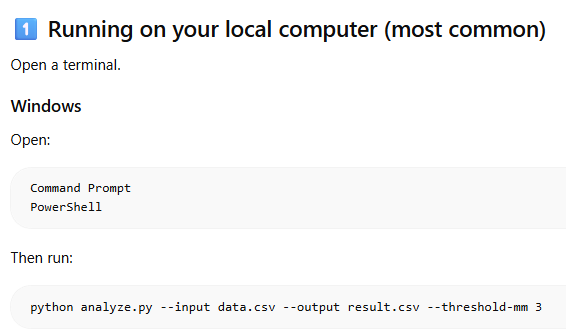

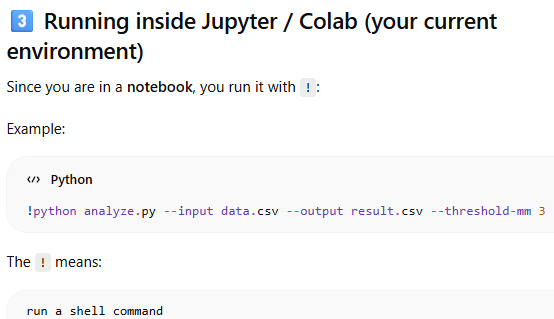

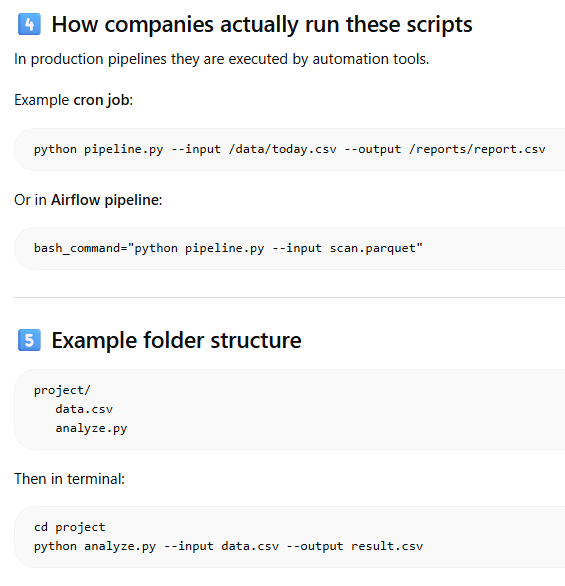

# SQL in Pyhton:

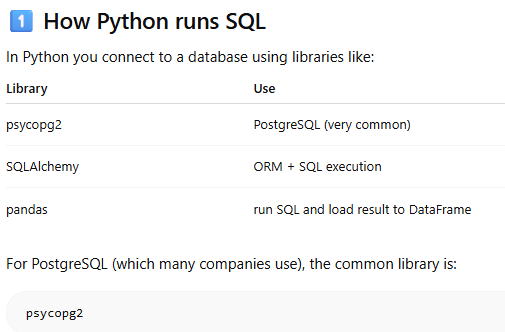

# Step 1: connect to database

In [ ]:
import psycopg2
conn=psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="123456"
)

cursor=conn.cursor()

# Step 2: run SQL query

using cursor:

In [ ]:
query="""
SELECT run_id,depth_m,defect_mm
FROM measurements
WHERE defect-mm >= 2.0
ORDER BY defetct-mm
LIMIT 20
"""

cursor.excute(query)
rows=cursur.fetchall()

for r in rows:
  print(r)

using Pandas:

In [ ]:
import pandas as pd
df=pd.read_sql(query,conn)
print(df.head())

# Example for JOIN:

In [ ]:
query="""
        SELECT run_id,depth_m,defect_mm,
        FROM runs r
        JOIN measurements m
        ON r.run_id=m.run_id
        """
pd.read_sql(query, conn)

# Group KPI example

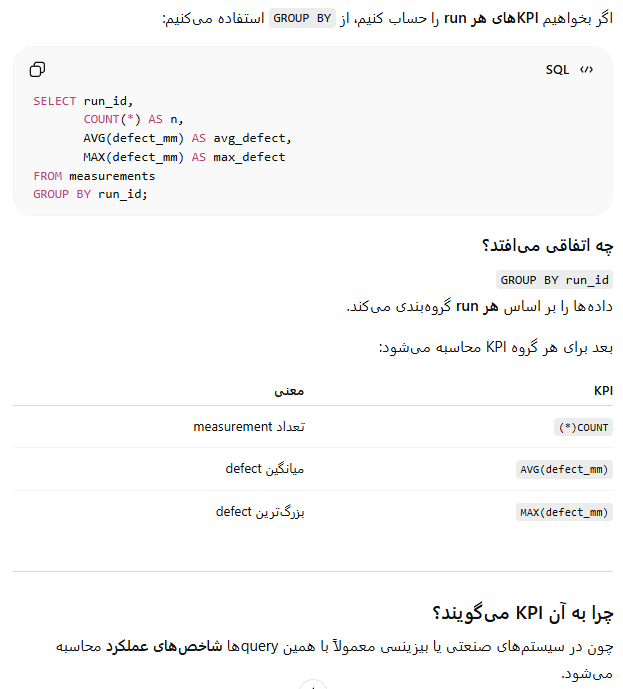

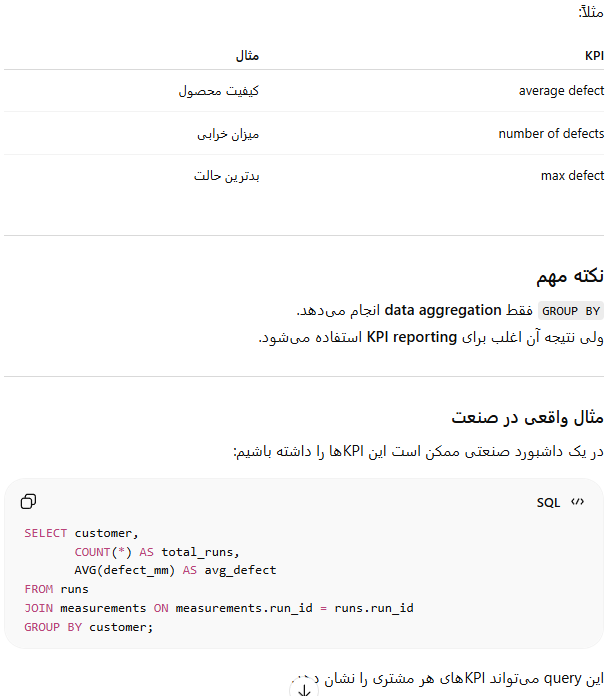

In [ ]:
query="""
SELECT run_id,
        COUNT(*) as n,
        AVG (defect_mm) AS avg_defect
FROM measurements
GROUP BY run_id
HAVING COUNT(*) > 10
ORDER BY n DESC
"""

df=pd.read_sql(query,conn)
df.head()

# Window function example

- ROW_NUMBER() | RANK() | DENSE_RANK()

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
          ROW_NUMBER() OVER (
                              PARTITION BY  run_id
                              ORDER BY defetct_mm DESC) AS RANK
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

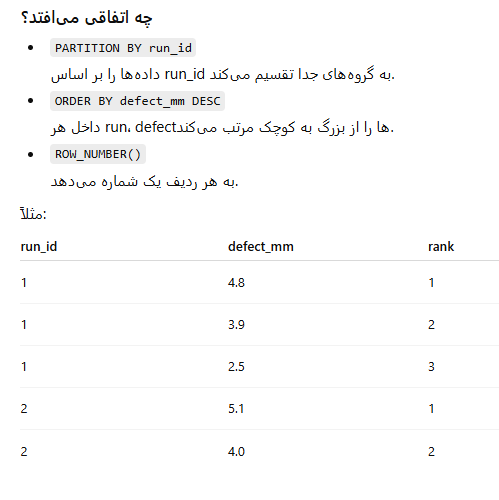

# Ranking functions
شماره یکتا برای هر ردیف

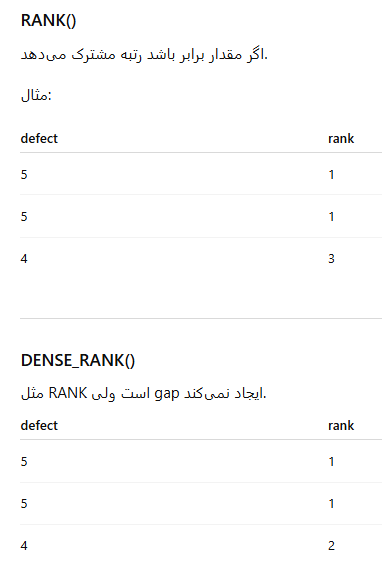

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
         RANK() OVER (
                              PARTITION BY  run_id
                              ORDER BY defetct_mm DESC) AS RANK
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
          DENSE_RANK() OVER (
                              PARTITION BY  run_id
                              ORDER BY defetct_mm DESC) AS RANK
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

# Aggregation window functions
- AVG


هر ردیف میانگین defect در همان run را نشان می‌دهد.

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
          AVG(defect_mm) OVER (
                              PARTITION BY  run_id) AS avg_defect
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

- SUM

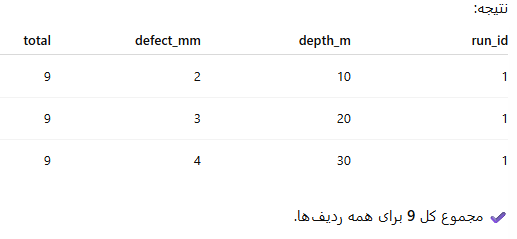

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
          SUM(defect_mm) OVER (
                              PARTITION BY  run_id) AS avg_defect
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

Running total (SUM with order BY)

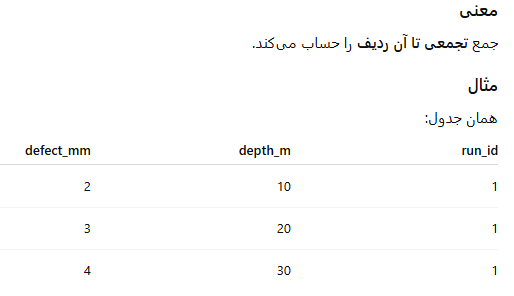

In [ ]:
query=""" SELECT run_id, depth_mm, defect_mm,
          SUM(defect_mm) OVER (
                              PARTITION BY  run_id
                               ORDER BY depth_m) AS avg_defect
          FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

# Offset functions

-  برای دسترسی به ردیف قبلی یا بعدی.

- LAG() => ردیف قبلی را نشان می‌دهد.
- LEAD() => ردیف بعدی را نشان می‌دهد.

In [ ]:
query=""" SELECT depth_m,
       defect_mm,
       LAG(defect_mm) OVER (ORDER BY depth_m) AS prev_defect
FROM measurements"""

df = pd.read_sql(query, conn)
df.head()

In [ ]:
query="""SELECT  depth_m,
       defect_mm,
       LEAD (defect_mm) OVER (ORDER BY depth_m) AS prev_defect
FROM measurements;"""

df = pd.read_sql(query, conn)
df.head()

# FIRST_VALUE
- بزرگ‌ترین defect را نشان می‌دهد.


In [ ]:
query="""SELECT  depth_m,
       defect_mm,
       FIRST_VALUE (defect_mm) OVER (PARTITION BY run_id
                                     ORDER BY defect_m) AS First_defect
        FROM measurements;"""

df = pd.read_sql(query, conn)
df.head()

# LAST_VALUE
- کوچک‌ترین defect را نشان می‌دهد.

In [ ]:
query="""SELECT  depth_m,
       defect_mm,
       LAST_VALUE (defect_mm) OVER (PARTITION BY run_id
                                     ORDER BY defect_m) AS First_defect
        FROM measurements;"""

df = pd.read_sql(query, conn)
df.head()

# تفاوت GROUP BY و Window Function

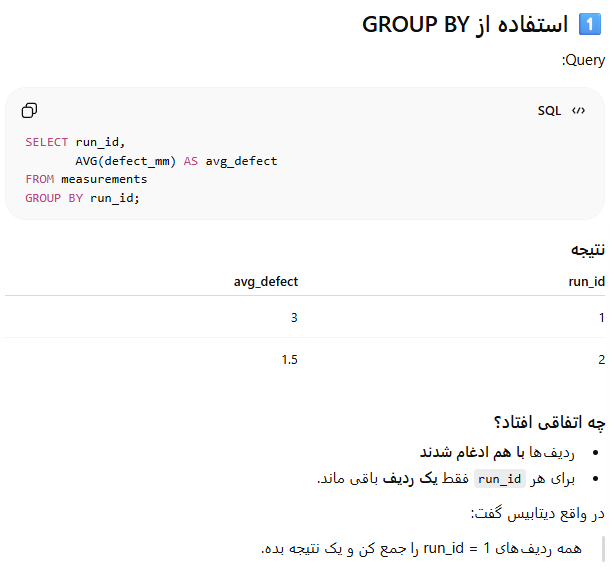

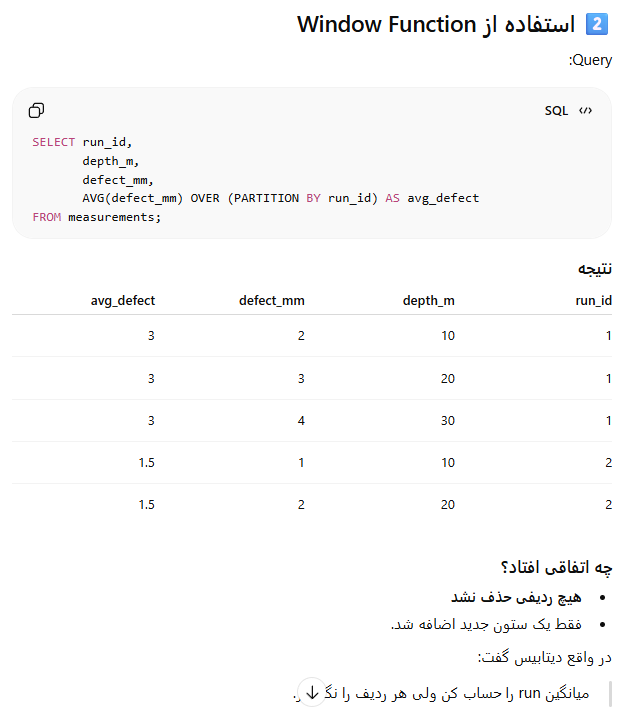

# Writing data from Python to database

%S => string | float | int

In [ ]:
query="""  INSERT INTO table(run_id,depth_m,defect_mm)
            VALUES (%s,%s,%s)""" , (run_1,45.2,2.3)

conn.commit()

# ****************When a Dataset is Huge (real prj) **************:


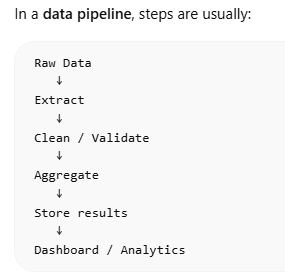

## 1) your goal is: don’t load everything, don’t loop in Python, and don’t recompute. Here are the core techniques a Data Python Developer should use.

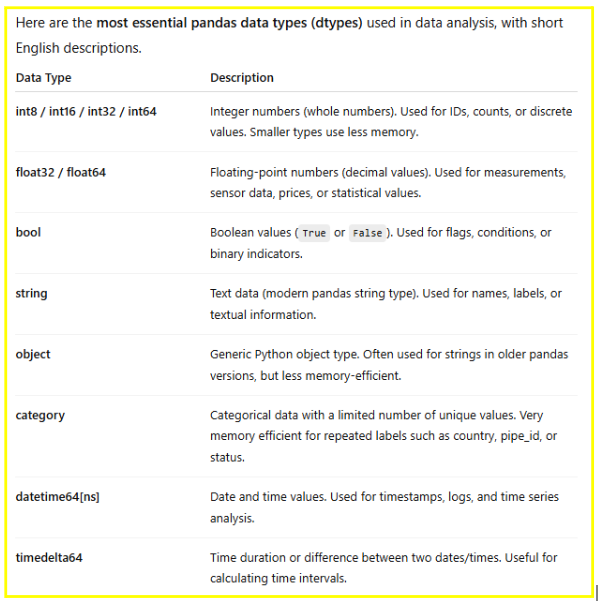

In [ ]:
import argpars

def argparser():
  p=argparse.ArgumentParser()
  p.add_argument("--input", required=True , help="Path to input CSV file")
  p.add_argument("--chunk-size",type=int,default=200000,help="Chunk size for processing")
  p.add_argument("--nrows",,type=int,default=1000000,help="row size for processing")
  p.add_argument("--output", required=True , help="Path to output CSV file")
  return p.parse_args()


# Columns we expect
REQUIRED_COLS = ["run_id", "pipe_id", "depth_m", "defect_mm", "timestamp"]

# Dtypes to reduce memory (adjust if your IDs are strings)
DTYPE = {
    "run_id": "string",
    "pipe_id": "category",
    "depth_m": "float32",
    "defect_mm": "string",   # read as string first, then coerce to numeric safely
    "timestamp": "string"
}

# Define essential arguments
args=argparser()
df=pd.read_csv( args.input , #"big.csv"
               usecols=REQUIED_COLS,
               dtype=DTYPE,
               nrows= args.nrow #1_000_000
                )

## 2) Process in chunks (streaming)
When the file is too big for RAM:


In [ ]:
#chunks=pd.read_csv("big.csv",chunksize='200_000')  or
chunks=pd.read_csv(args.input,chunksize=args.chunk_size)

for chunk in chunks:
  chunk["defet_num"]=pd.to_numeric(chunk["defet_num"], errors="coerce")

## 3)  Clean + Validate a big CSV
- validate rules

- return good rows + bad rows with reasons

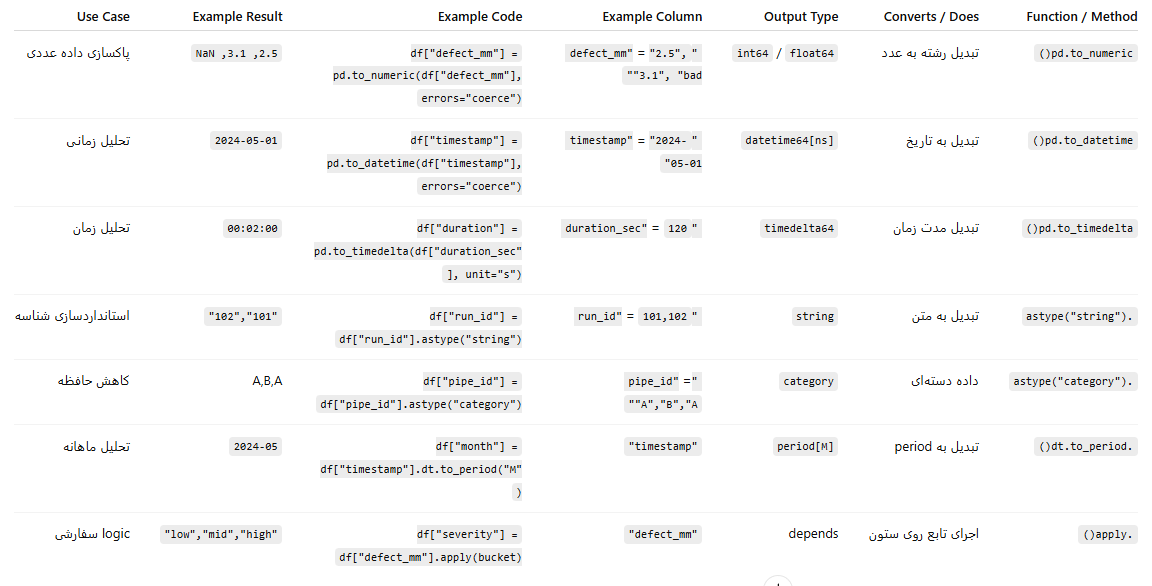



*  .str.strip() این تابع space های ابتدا و انتهای متن را حذف می‌کند.

* astype("string") این قسمت نوع داده ستون را
تبدیل می‌کند به: pandas string type

* missing_required = df[REQUIRED].isna().any(axis=1) ⇒  هر سطری که مقدارNON دارد  True برمیگرداندو بعدا میتوان سطرهای خراب را حذف کرد

* bad_depth = (df["depth_m"] < 0) | (df["depth_m"] > 50_000) =>  این خط کد یک شرط (condition) روی ستون depth_m می‌سازد و خروجی آن یک Series از نوع Boolean (True/False) است.

* در پایتون می‌توان داخل عدد از _ استفاده کرد تا خواندن آن راحت‌تر شود.  50_000

* str.len() == 0 => این بررسی می‌کند که رشته خالی باشد.

* isna() => این فقط مقادیر NULL / NaN را پیدا می‌کند.

* ~ = Not

* bad.loc[missing_required, "reason"] += "missing_required;" =>
 برای سطرهایی که missing_required=True است  متن missing_required; را به reason اضافه کن

* df.loc[rows, columns]

* run_invalid = df["run_id"].str.len().fillna(0).eq(0)  آیا طول رشته برابر صفر است؟








In [ ]:
import logging

logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

def clean_and_validate(chunck:pd.DataFrame):

  # 1) keep only required columns
  df=chunck[REQUIRED_COLS].copy()

  # 2) Basic cleanup (strip/remove space)
  df["run_id"]=df["run_id"].astype("string").str.strip()
  df["pipe_id"]=df["pipe_id"].astype("string").str.strip()

  # 3) safe type conversion
  df["depth_m"]=pd.to_numeric(df["depth_m"],errors="coerce")
  df["defect_mm"] = pd.to_numeric(df["defect_mm"], errors="coerce")
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

  # 4) validation rules (adjust ranges for your project)
  missing_row_cell=df[REQUIRED_COLS].isna().any(axis=1)
       # check for invalid data range
  bad_depth = (df["depth_m"] < 0) | (df["depth_m"] > 50_000)
  bad_defect = (df["defect_mm"] < 0) | (df["defect_mm"] > 500)
       #find empty id
  empty_ids=(df["run_id"].str.len()==0) | (df["pipe_id"].str.len()==0)

  # any invalid row is True and Valid row is False
  invalid_row=missing_row_cell | bad_depth | bad_defect | empty_ids

  # 5) split good and bad rows
     # valid_rows are False => ~False => True
  good_rows=df.loc[~invalid_row].copy()
     # invalid_rows are True
  bad_row=df.loc[invalid_row].copy()

  # 6) add simple reason column to bad rows dataset
  bad_row["reason"]=""
  bad_row.loc[missing_row_cell,"reason"] += "missing_required;"
  bad_row.loc[bad_depth,"reason"] += "invalid_depth;"
  bad_row.loc[bad_defect,"reason"] += "invalid_defect;"
  bad_row.loc[empty_ids,"reason"] += "invalid_id;"

  # 7) # logging summary
  logging.info(f"Row with missing_required:{missing_row_cell..sum()}")
  logging.info(f"Rows with bad_depth: {bad_depth.sum()}")
  logging.info(f"Rows with bad_defect: {bad_defect.sum()}")
  logging.info(f"Rows with empty_ids: {empty_ids.sum()}")


  return good_rows,bad_row


# 4) Aggregate | KPI (doing  aggregate func on a column) | groupby

In [ ]:
def aggregate_chunk(clean_df: pd.DataFrame) -> pd.DataFrame:
    """
    Example aggregation:
      - count rows per run_id
      - avg/max defect per run_id
      - min/max timestamp per run_id
    """
    agg = clean_df.groupby("run_id").agg(
        n=("defect_mm", "size"),
        avg_defect=("defect_mm", "mean"),
        max_defect=("defect_mm", "max"),
        min_depth=("depth_m", "min"),
        max_depth=("depth_m", "max"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    )
    return agg


## 4-1)
- this part is not professional but we can use instead of part 5
-  final = pd.concat(agg_results):
    -  این خط کد در pandas برای ترکیب چند DataFrame در یک DataFrame واحد استفاده می‌شود.

In [ ]:
# chunks = pd.read_csv("big.csv", chunksize=200000)

# agg_results = []

# for chunk in chunks:

#     clean, bad = clean_and_validate(chunk)

#     agg = aggregate_chunk(clean)

#     agg_results.append(agg)

# final = pd.concat(agg_results)
# final.reset_index().to_csv("run_summary.csv", index=False)


## 4-2)
- level=0 is used when grouping by the index instead of a column. when we write groupby("run_id") thes run_id is not column anymore but it is index(level=0)
 final = combined.groupby(level=0)

- Indexes can have multiple levels (MultiIndex).
like:
level 0 → run_id
level 1 → pipe_id

- Your current pipeline will produce duplicate run_id rows.  So you should aggregate again at the end:


In [ ]:
def combine_aggregates(agg_parts: list[pd.DataFrame]) -> pd.DataFrame:
    combined = pd.concat(agg_parts)  # run_id is index
    final = combined.groupby(level=0).agg(
        n=("n", "sum"),
        sum_defect=("sum_defect", "sum"),
        max_defect=("max_defect", "max"),
        min_depth=("min_depth", "min"),
        max_depth=("max_depth", "max"),
        first_seen=("first_seen", "min"),
        last_seen=("last_seen", "max"),
    )
    #for Chunck format we can't calculate one avg(like above) ==> we have to calculate like below
    final["avg_defect"] = final["sum_defect"] / final["n"]
    final = final.reset_index()  # bring run_id back as a column
    return final




# 5)  main function  to load clean and validate and aggregate functions


- if i % 5 == 0 => This line is a progress report during the pipeline execution. It prints a status message every 5 chunks processed so you can see that the program is working and how much data has been processed.

In [ ]:
def main():
    args = parse_args()
    setup_logging(args.log_file)

    chunks = pd.read_csv(
        args.input,
        chunksize=args.chunk_size,
        usecols=REQUIRED_COLS,
        dtype=DTYPE,
        nrows=args.nrows
    )

    agg_parts = []
    bad_parts = []

    total_rows = kept_rows = bad_rows = 0

    for i, chunk in enumerate(chunks, start=1):
        total_rows += len(chunk)

        clean_df, bad_df = clean_and_validate(chunk)
        kept_rows += len(clean_df)
        bad_rows += len(bad_df)

        if not bad_df.empty:
            bad_parts.append(bad_df)

        if not clean_df.empty:
            agg_parts.append(aggregate_chunk(clean_df))

        if i % 5 == 0:
            print(f"Processed chunks={i} | total={total_rows:,} kept={kept_rows:,} bad={bad_rows:,}")

    if agg_parts:
        final = combine_aggregates(agg_parts)
        final.to_csv(args.output, index=False)
    else:
        # no valid rows
        pd.DataFrame(columns=["run_id","n","sum_defect","max_defect","min_depth","max_depth","first_seen","last_seen","avg_defect"]) \
          .to_csv(args.output, index=False)

    if bad_parts:
        bad_all = pd.concat(bad_parts, ignore_index=True)
        bad_all.to_csv(args.bad_output, index=False)

    print("\nDONE")
    print(f"Total rows read: {total_rows:,}")
    print(f"Valid rows kept: {kept_rows:,}")
    print(f"Invalid rows dropped: {bad_rows:,}")
    print(f"Outputs: {args.output}" + (f", {args.bad_output}" if bad_parts else ""))

if __name__ == "__main__":
    main()

# complete   ETL script (1 to 5)
- Here’s a **more complete, real-world chunk ETL script** you can use to clean + validate a big CSV. It shows common validations, error logging, and aggregation—without loading the whole file into RAM.


In [ ]:
```python
import argparse
import logging
import pandas as pd

REQUIRED_COLS = ["run_id", "pipe_id", "depth_m", "defect_mm", "timestamp"]

DTYPE = {
    "run_id": "string",
    "pipe_id": "category",
    "depth_m": "string",      # read as string first, then coerce safely
    "defect_mm": "string",    # read as string first, then coerce safely
    "timestamp": "string"
}

def parse_args():
    p = argparse.ArgumentParser(description="Chunk ETL: clean/validate + aggregate KPIs per run_id")
    p.add_argument("--input", required=True, help="Path to input CSV file")
    p.add_argument("--output", required=True, help="Path to output KPI CSV file (per run_id)")
    p.add_argument("--bad-output", default="bad_rows.csv", help="Path to bad rows CSV file")
    p.add_argument("--chunk-size", type=int, default=200_000, help="Chunk size for processing")
    p.add_argument("--nrows", type=int, default=None, help="Optional: read only first N rows")
    p.add_argument("--log-file", default="pipeline.log", help="Log file path")
    return p.parse_args()

def setup_logging(log_file: str):
    logging.basicConfig(
        filename=log_file,
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s"
    )

def clean_and_validate(chunk: pd.DataFrame):
    df = chunk[REQUIRED_COLS].copy()

    # strip spaces
    df["run_id"] = df["run_id"].astype("string").str.strip()
    df["pipe_id"] = df["pipe_id"].astype("string").str.strip()

    # safe conversions
    df["depth_m"] = pd.to_numeric(df["depth_m"], errors="coerce")
    df["defect_mm"] = pd.to_numeric(df["defect_mm"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    # validation rules (adjust thresholds as needed)
    missing_required = df[REQUIRED_COLS].isna().any(axis=1)
    bad_depth = (df["depth_m"] < 0) | (df["depth_m"] > 50_000)
    bad_defect = (df["defect_mm"] < 0) | (df["defect_mm"] > 500)
    empty_ids = (df["run_id"].str.len().fillna(0) == 0) | (df["pipe_id"].str.len().fillna(0) == 0)

    invalid = missing_required | bad_depth | bad_defect | empty_ids

    good = df.loc[~invalid].copy()
    bad = df.loc[invalid].copy()

    # reasons for invalid rows
    if not bad.empty:
        bad["reason"] = ""
        bad.loc[missing_required, "reason"] += "missing_required;"
        bad.loc[bad_depth, "reason"] += "invalid_depth;"
        bad.loc[bad_defect, "reason"] += "invalid_defect;"
        bad.loc[empty_ids, "reason"] += "invalid_id;"

    # log summary
    logging.info(f"chunk_rows={len(df)} good={len(good)} bad={len(bad)} "
                 f"missing_required={int(missing_required.sum())} bad_depth={int(bad_depth.sum())} "
                 f"bad_defect={int(bad_defect.sum())} empty_ids={int(empty_ids.sum())}")

    return good, bad

def aggregate_chunk(clean_df: pd.DataFrame) -> pd.DataFrame:
    # include sum_defect so final avg is weighted correctly
    agg = clean_df.groupby("run_id").agg(
        n=("defect_mm", "size"),
        sum_defect=("defect_mm", "sum"),
        max_defect=("defect_mm", "max"),
        min_depth=("depth_m", "min"),
        max_depth=("depth_m", "max"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    )
    return agg

def combine_aggregates(agg_parts: list[pd.DataFrame]) -> pd.DataFrame:
    combined = pd.concat(agg_parts)  # run_id is index
    final = combined.groupby(level=0).agg(
        n=("n", "sum"),
        sum_defect=("sum_defect", "sum"),
        max_defect=("max_defect", "max"),
        min_depth=("min_depth", "min"),
        max_depth=("max_depth", "max"),
        first_seen=("first_seen", "min"),
        last_seen=("last_seen", "max"),
    )
    final["avg_defect"] = final["sum_defect"] / final["n"]
    final = final.reset_index()  # bring run_id back as a column
    return final

def main():
    args = parse_args()
    setup_logging(args.log_file)

    chunks = pd.read_csv(
        args.input,
        chunksize=args.chunk_size,
        usecols=REQUIRED_COLS,
        dtype=DTYPE,
        nrows=args.nrows
    )

    agg_parts = []
    bad_parts = []

    total_rows = kept_rows = bad_rows = 0

    for i, chunk in enumerate(chunks, start=1):
        total_rows += len(chunk)

        clean_df, bad_df = clean_and_validate(chunk)
        kept_rows += len(clean_df)
        bad_rows += len(bad_df)

        if not bad_df.empty:
            bad_parts.append(bad_df)

        if not clean_df.empty:
            agg_parts.append(aggregate_chunk(clean_df))

        if i % 5 == 0:
            print(f"Processed chunks={i} | total={total_rows:,} kept={kept_rows:,} bad={bad_rows:,}")

    if agg_parts:
        final = combine_aggregates(agg_parts)
        final.to_csv(args.output, index=False)
    else:
        # no valid rows
        pd.DataFrame(columns=["run_id","n","sum_defect","max_defect","min_depth","max_depth","first_seen","last_seen","avg_defect"]) \
          .to_csv(args.output, index=False)

    if bad_parts:
        bad_all = pd.concat(bad_parts, ignore_index=True)
        bad_all.to_csv(args.bad_output, index=False)

    print("\nDONE")
    print(f"Total rows read: {total_rows:,}")
    print(f"Valid rows kept: {kept_rows:,}")
    print(f"Invalid rows dropped: {bad_rows:,}")
    print(f"Outputs: {args.output}" + (f", {args.bad_output}" if bad_parts else ""))

if __name__ == "__main__":
    main()
```


# Partition your data
- Save data separated by date/run/pipe so you only read a part.
- Example folder layout:
- data/year=2026/month=03/day=01/part-000.parquet

- Then read only the partitions you need.


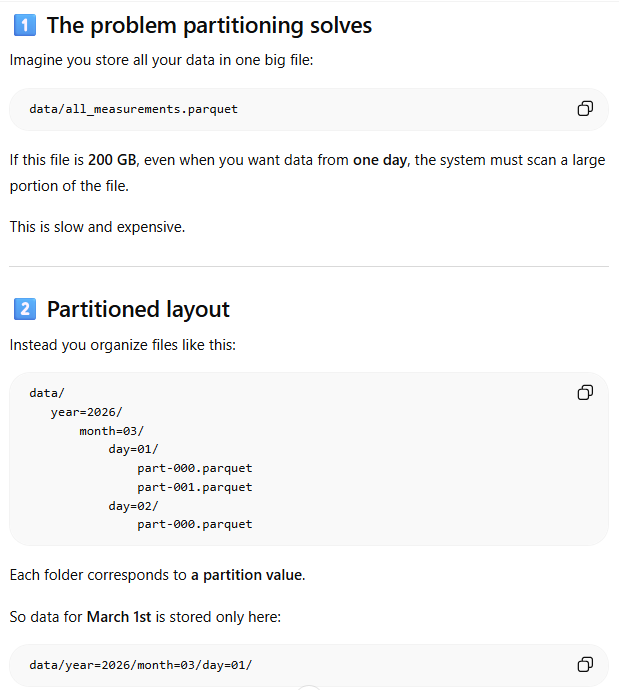

# inspect how much memory your DataFrame uses.
- They are part of performance debugging when working with large datasets.

- When working with large CSVs or big data, it’s common to run out of RAM or experience slow processing. These checks help you understand memory usage and optimize your pipeline.

# When you should run these checks

You usually run them:

- when reading big datasets

- when optimizing pipelines

- when debugging slow scripts

- during data engineering development

- during memory errors

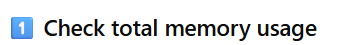

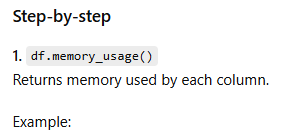

2. deep=True:
- Normally pandas only measures shallow memory.For object/string columns it underestimates.deep=True tells pandas to measure real memory usage.

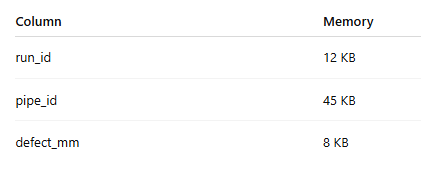

3. .sum() : Adds all column memory together.

4. / 1024**2 : Converts bytes → megabytes

- Example result:   245.6   => Meaning:  DataFrame uses ~245 MB RAM

In [ ]:
# This calculates the total memory used by the DataFrame in MB.
df.memory_usage(deep=True).sum() /1024**2

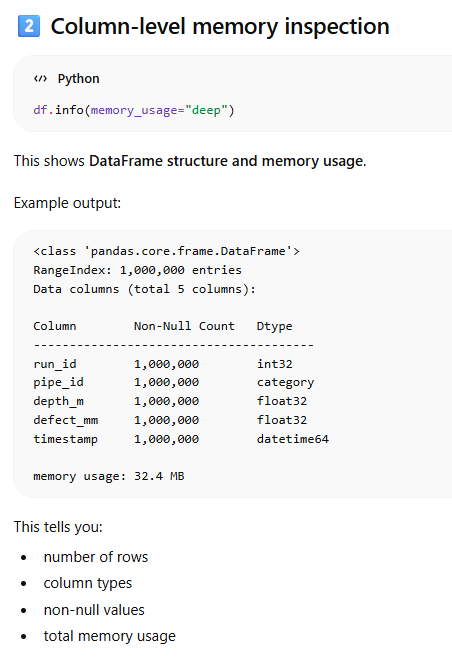